<a href="https://colab.research.google.com/github/spsaraniit-hash/pocket-smart-ai-/blob/main/Stock_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Data downloaded successfully!
Total records: 1487

========== DATA PREVIEW ==========
Price              Open         High          Low        Close   Volume
Date                                                                   
2020-01-01  2168.000000  2183.899902  2154.000000  2167.600098  1354908
2020-01-02  2179.949951  2179.949951  2149.199951  2157.649902  2380752
2020-01-03  2164.000000  2223.000000  2164.000000  2200.649902  4655761
2020-01-06  2205.000000  2225.949951  2187.899902  2200.449951  3023209
2020-01-07  2200.500000  2214.649902  2183.800049  2205.850098  2429317

========== STATISTICS ==========
Price         Open         High          Low        Close        Volume
count  1487.000000  1487.000000  1487.000000  1487.000000  1.487000e+03
mean   3312.067822  3342.884697  3280.482455  3310.803763  2.689371e+06
std     603.087837   605.207689   600.648457   602.966912  1.611341e+06
min    1559.699951  1685.449951  1506.050049  1636.349976  0.000000e+00
25%    3097.94

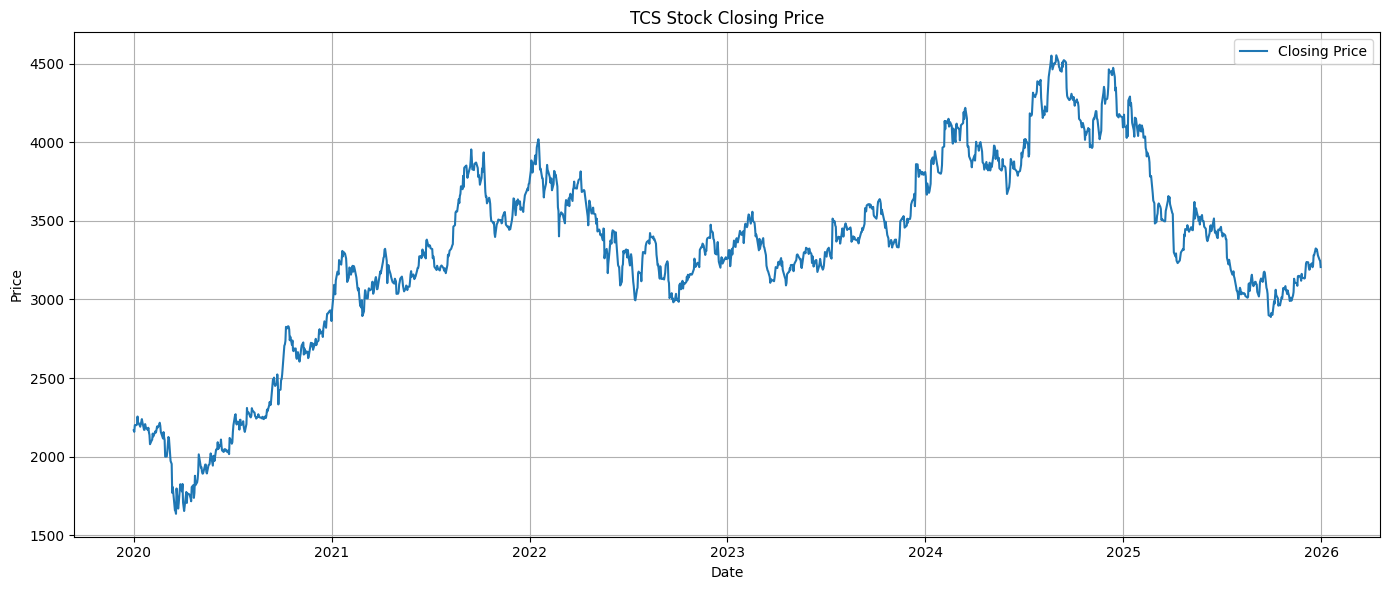

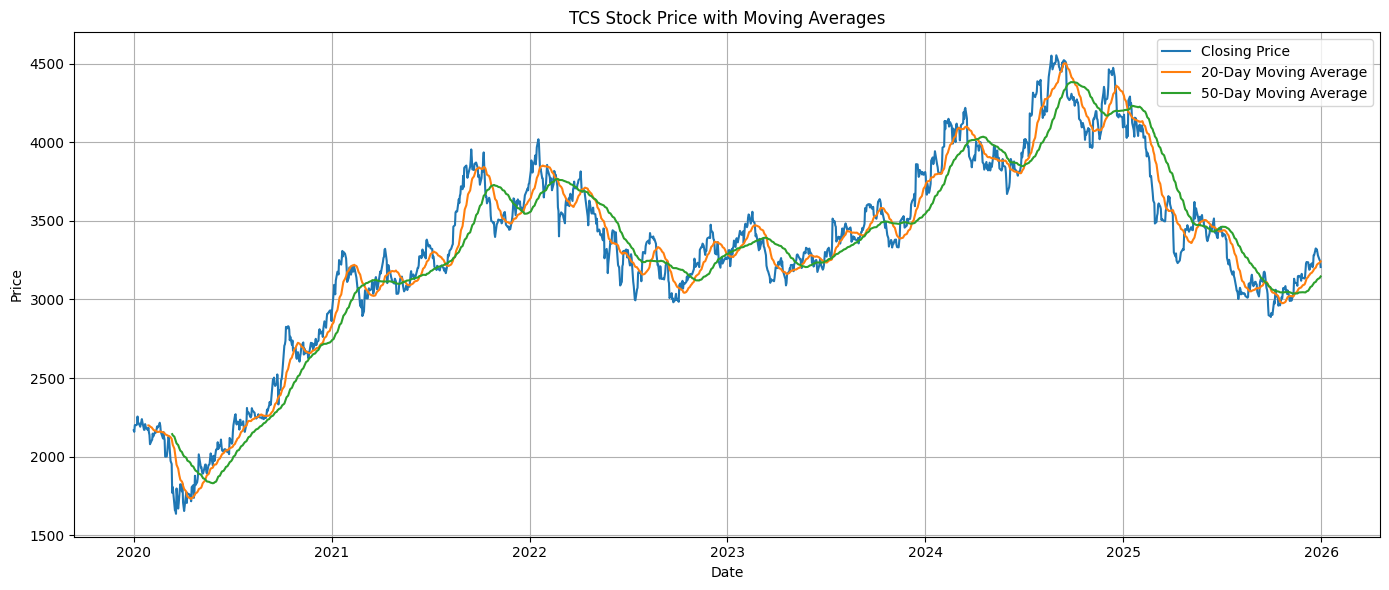

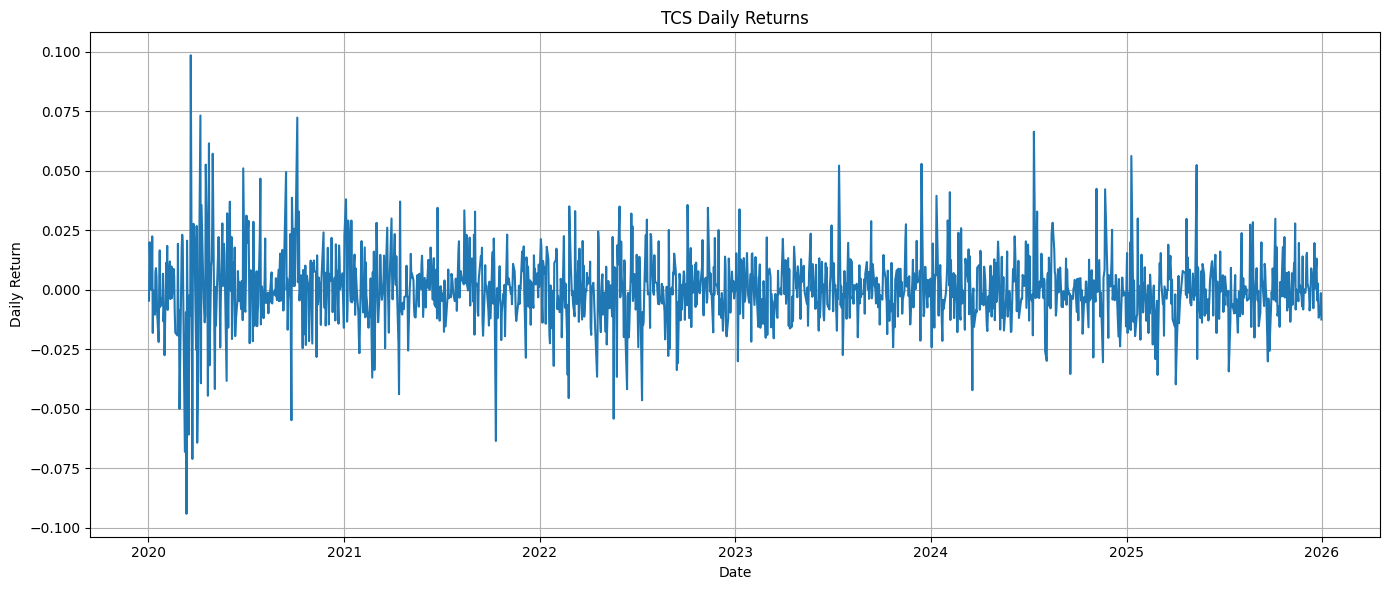

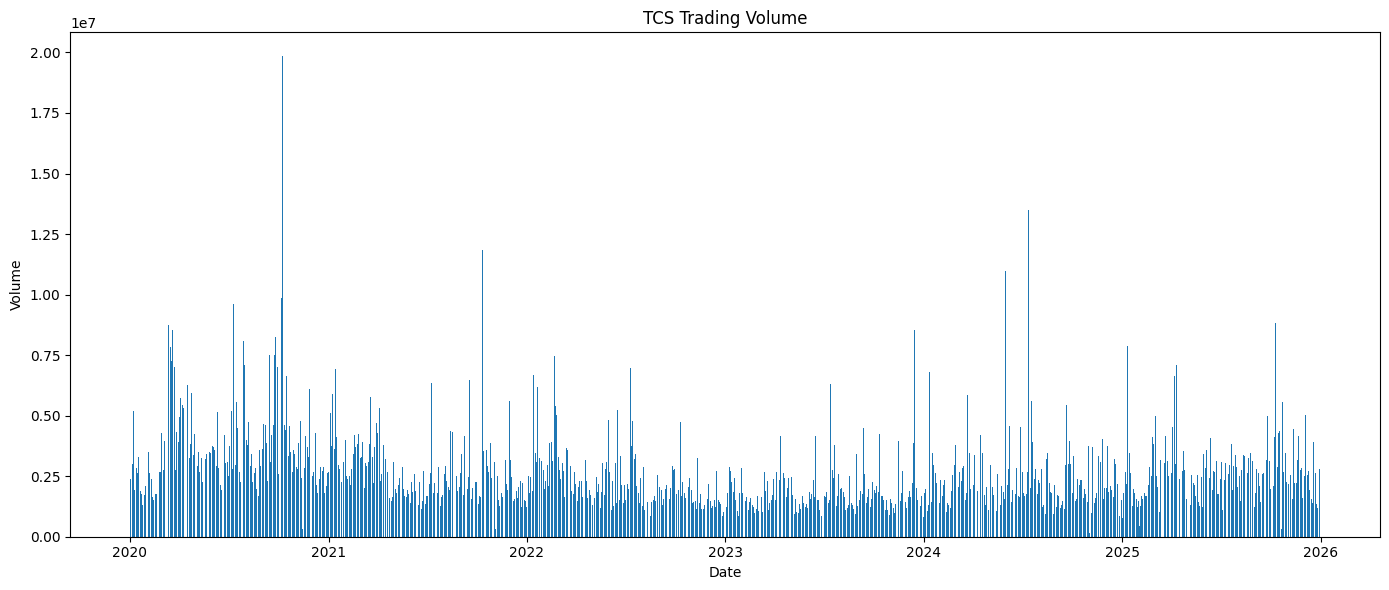


========== MACHINE LEARNING ==========
Training data: 1150
Testing data: 288
✅ Machine Learning model trained successfully!

========== MODEL PERFORMANCE ==========
MAE       : 32.85
MSE       : 2161.63
RMSE      : 46.49
R² Score  : 0.9889


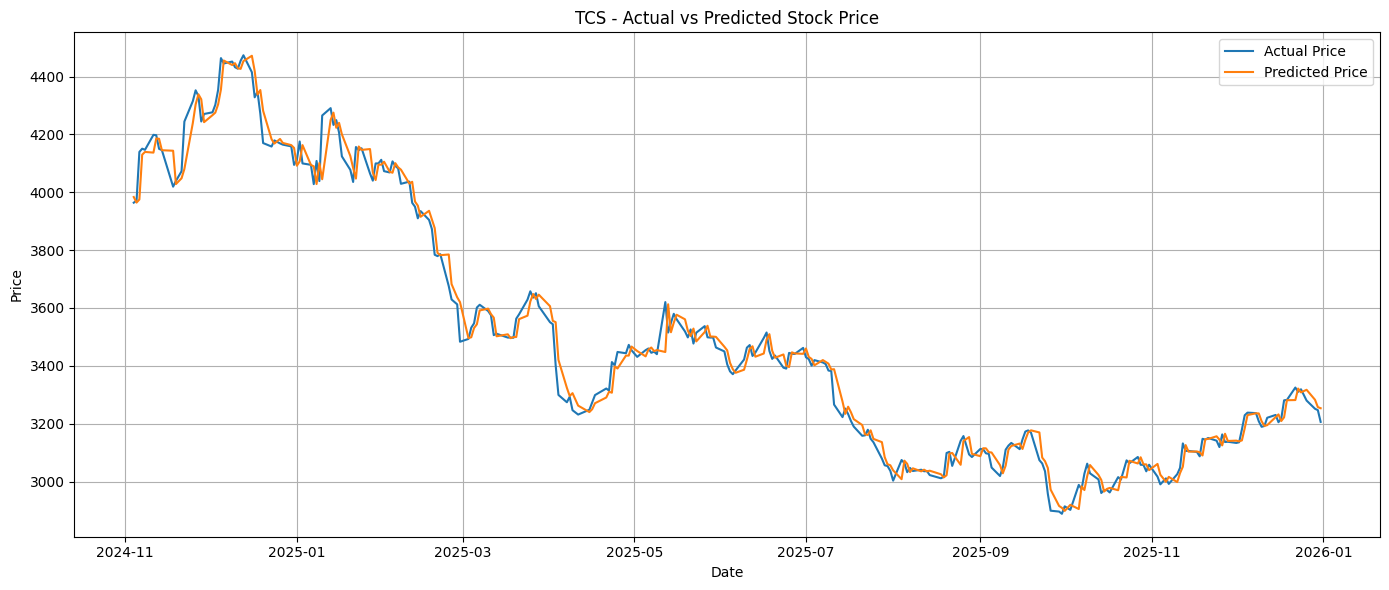


========== PREDICTION RESULTS ==========
            Actual Price  Predicted Price
Date                                     
2025-12-17   3217.800049      3209.164248
2025-12-18   3280.800049      3221.972150
2025-12-19   3282.000000      3281.114637
2025-12-22   3324.899902      3281.714763
2025-12-23   3310.000000      3321.421791
2025-12-24   3319.000000      3308.318885
2025-12-26   3280.000000      3317.183088
2025-12-29   3251.500000      3282.662780
2025-12-30   3246.800049      3257.322842
2025-12-31   3206.199951      3253.384721

       STOCK MARKET ANALYSIS SUMMARY
Stock                  : TCS.NS
Total Records          : 1487
Latest Actual Price    : 3206.2
Latest Predicted Price : 3253.38
R² Score               : 0.9889

✅ PROJECT COMPLETED SUCCESSFULLY!
✅ CSV file created: stock_prediction_results.csv


In [1]:
# ============================================================
# STOCK MARKET ANALYSIS USING PYTHON & MACHINE LEARNING
# ============================================================

!pip -q install yfinance scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. STOCK SELECTION
# ------------------------------------------------------------

ticker = "TCS.NS"

print("Downloading stock data...")

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)

# Fix yfinance MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.loc[:, ~data.columns.duplicated()]

# Keep required columns
data = data[["Open", "High", "Low", "Close", "Volume"]]

# Convert to numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna()

print("✅ Data downloaded successfully!")
print("Total records:", len(data))

# ------------------------------------------------------------
# 2. BASIC INFORMATION
# ------------------------------------------------------------

print("\n========== DATA PREVIEW ==========")
print(data.head())

print("\n========== STATISTICS ==========")
print(data.describe())

# ------------------------------------------------------------
# 3. MOVING AVERAGES
# ------------------------------------------------------------

data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

# ------------------------------------------------------------
# 4. DAILY RETURNS
# ------------------------------------------------------------

data["Daily Return"] = data["Close"].pct_change()

# ------------------------------------------------------------
# 5. STOCK PRICE CHART
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(data.index, data["Close"], label="Closing Price")
plt.title("TCS Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. MOVING AVERAGE CHART
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(data.index, data["Close"], label="Closing Price")
plt.plot(data.index, data["MA20"], label="20-Day Moving Average")
plt.plot(data.index, data["MA50"], label="50-Day Moving Average")

plt.title("TCS Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. DAILY RETURN CHART
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(data.index, data["Daily Return"])

plt.title("TCS Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. TRADING VOLUME
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.bar(
    data.index,
    data["Volume"].astype(float),
    width=1
)

plt.title("TCS Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. MACHINE LEARNING DATA
# ------------------------------------------------------------

ml_data = data.copy()

ml_data["Previous_Close"] = ml_data["Close"].shift(1)
ml_data["MA10"] = ml_data["Close"].rolling(10).mean()
ml_data["MA20_ML"] = ml_data["Close"].rolling(20).mean()

ml_data = ml_data.dropna()

X = ml_data[
    [
        "Previous_Close",
        "MA10",
        "MA20_ML",
        "Volume"
    ]
]

y = ml_data["Close"]

# ------------------------------------------------------------
# 10. TRAIN / TEST SPLIT
# ------------------------------------------------------------

split = int(len(ml_data) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("\n========== MACHINE LEARNING ==========")
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

# ------------------------------------------------------------
# 11. TRAIN MODEL
# ------------------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

print("✅ Machine Learning model trained successfully!")

# ------------------------------------------------------------
# 12. PREDICTION
# ------------------------------------------------------------

predictions = model.predict(X_test)

# ------------------------------------------------------------
# 13. MODEL EVALUATION
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n========== MODEL PERFORMANCE ==========")
print("MAE       :", round(mae, 2))
print("MSE       :", round(mse, 2))
print("RMSE      :", round(rmse, 2))
print("R² Score  :", round(r2, 4))

# ------------------------------------------------------------
# 14. ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Price"
)

plt.plot(
    y_test.index,
    predictions,
    label="Predicted Price"
)

plt.title("TCS - Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. RESULT TABLE
# ------------------------------------------------------------

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
}, index=y_test.index)

print("\n========== PREDICTION RESULTS ==========")
print(result.tail(10))

# Save CSV
result.to_csv("stock_prediction_results.csv")

# ------------------------------------------------------------
# 16. FINAL SUMMARY
# ------------------------------------------------------------

latest_actual = float(y_test.iloc[-1])
latest_predicted = float(predictions[-1])

print("\n============================================")
print("       STOCK MARKET ANALYSIS SUMMARY")
print("============================================")
print("Stock                  :", ticker)
print("Total Records          :", len(data))
print("Latest Actual Price    :", round(latest_actual, 2))
print("Latest Predicted Price :", round(latest_predicted, 2))
print("R² Score               :", round(r2, 4))
print("============================================")

print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")
print("✅ CSV file created: stock_prediction_results.csv")